# CUPED e redução de variância

**Tema:** Estatística › A/B Testing e Desenho Experimental

O tamanho de amostra necessário é proporcional à variância da métrica:
$n \propto \sigma^2/\Delta^2$. Isso significa que **cortar a variância pela
metade tem exatamente o mesmo efeito que dobrar o tráfego** — e é muito mais
barato.

Este notebook implementa as três técnicas que a indústria usa: CUPED,
estratificação e winsorização. Todas atacam o mesmo alvo pelo mesmo motivo.

> **A ideia do CUPED em uma frase:** boa parte da variação entre usuários já
> existia **antes** do experimento. Se você mediu isso, pode subtrair — e o que
> sobra é ruído menor, com o efeito do tratamento intacto.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(80808)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. O problema: variância como imposto sobre o tráfego

In [2]:
def n_necessario(sigma, mde_absoluto, alfa=0.05, poder=0.80):
    z = stats.norm.isf(alfa / 2) + stats.norm.isf(1 - poder)
    return int(np.ceil(2 * sigma**2 * z**2 / mde_absoluto**2))


MDE = 1.5   # reais por usuário
print(f"{'redução de variância':<26s} {'σ':>8s} {'n por grupo':>14s} {'economia':>10s}")
print("-" * 62)
n_base = n_necessario(50, MDE)
for reducao in [0.0, 0.20, 0.40, 0.50, 0.65]:
    sigma = 50 * np.sqrt(1 - reducao)
    n = n_necessario(sigma, MDE)
    print(f"{reducao:>24.0%}  {sigma:>8.2f} {n:>14,} {1 - n/n_base:>9.0%}")

redução de variância              σ    n por grupo   economia
--------------------------------------------------------------
                      0%     50.00         17,442        0%
                     20%     44.72         13,954       20%
                     40%     38.73         10,466       40%
                     50%     35.36          8,721       50%
                     65%     29.58          6,105       65%


**A relação é linear:** reduzir a variância em 40% reduz o tráfego necessário
em 40%. Um experimento que levaria 20 dias passa a levar 12.

Em times que rodam centenas de experimentos por trimestre, isso não é
otimização — é a diferença entre testar 100 ideias por ano e testar 170.

## 2. CUPED: a mecânica

$$Y_{\text{cuped}} = Y - \theta(X - \bar{X}), \qquad
\theta = \frac{\mathrm{Cov}(Y, X)}{\mathrm{Var}(X)}$$

onde $X$ é uma covariável medida **antes** do experimento — quase sempre a
mesma métrica no período anterior.

**Por que é não-viesado:** $X$ é anterior ao tratamento, logo $\mathbb{E}[X]$ é
a mesma nos dois grupos. Subtrair algo com a mesma média dos dois lados não
muda a diferença estimada — só reduz a dispersão em torno dela.

In [3]:
N = 60_000
EFEITO = 1.8          # o tratamento vale R$ 1,80 por usuário

# nível de gasto de cada usuário: a fonte da variação que já existia
nivel = rng.gamma(2.0, 25.0, N)

# X: gasto no período ANTERIOR ao experimento (covariável pré-tratamento)
x_pre = nivel + rng.normal(0, 22, N)

grupo = rng.random(N) < 0.5
# Y: gasto durante o experimento — mesmo nível de base + efeito + ruído novo
y = nivel + EFEITO * grupo + rng.normal(0, 22, N)

rho = np.corrcoef(y, x_pre)[0, 1]
print(f"correlação entre Y e X pré-experimento: ρ = {rho:.4f}")
print(f"redução de variância teórica (1 - ρ²):  {rho**2:.1%}")

correlação entre Y e X pré-experimento: ρ = 0.7236
redução de variância teórica (1 - ρ²):  52.4%


theta estimado: 0.7232

                    variância   EP da dif.  efeito est.    p-valor
--------------------------------------------------------------------
sem CUPED              1740.4       0.3406       1.4614  1.779e-05
com CUPED               829.1       0.2350       1.8833  1.101e-15

efeito verdadeiro: 1.8000
redução de variância obtida: 52.4%


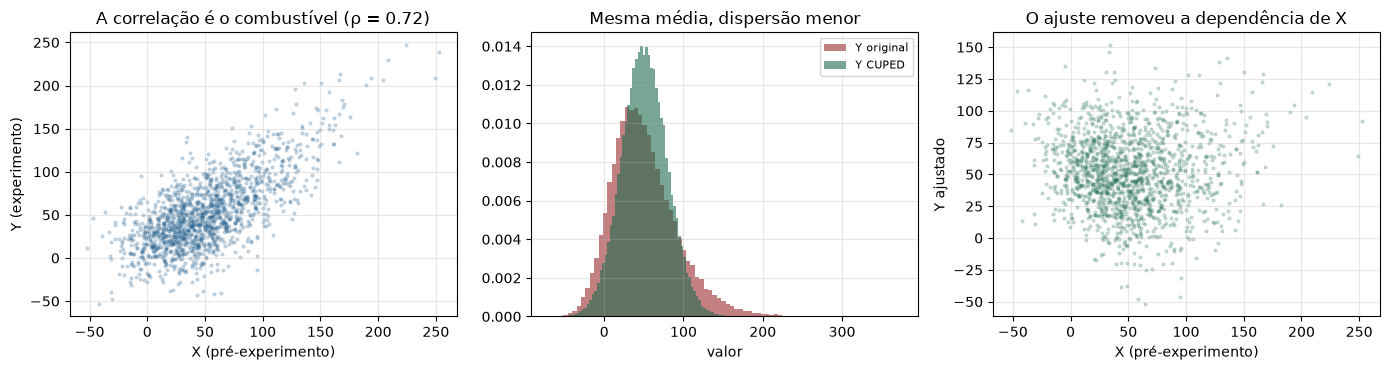

In [4]:
def aplica_cuped(y, x):
    """Devolve Y ajustado e o theta usado. X DEVE ser pré-tratamento."""
    theta = np.cov(y, x)[0, 1] / np.var(x, ddof=1)
    return y - theta * (x - x.mean()), theta


y_cuped, theta = aplica_cuped(y, x_pre)

print(f"theta estimado: {theta:.4f}\n")
print(f"{'':<16s} {'variância':>12s} {'EP da dif.':>12s} {'efeito est.':>12s} {'p-valor':>10s}")
print("-" * 68)
for nome, yy in [("sem CUPED", y), ("com CUPED", y_cuped)]:
    c, t = yy[~grupo], yy[grupo]
    dif = t.mean() - c.mean()
    ep = np.sqrt(c.var(ddof=1) / len(c) + t.var(ddof=1) / len(t))
    p = 2 * stats.norm.sf(abs(dif / ep))
    print(f"{nome:<16s} {yy.var(ddof=1):>12.1f} {ep:>12.4f} {dif:>12.4f} {p:>10.4g}")
print(f"\nefeito verdadeiro: {EFEITO:.4f}")
print(f"redução de variância obtida: {1 - y_cuped.var(ddof=1)/y.var(ddof=1):.1%}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].scatter(x_pre[::40], y[::40], s=4, alpha=0.2, color=AZUL)
axes[0].set_xlabel("X (pré-experimento)"); axes[0].set_ylabel("Y (experimento)")
axes[0].set_title(f"A correlação é o combustível (ρ = {rho:.2f})")

axes[1].hist(y, bins=80, alpha=0.6, color=VERMELHO, density=True, label="Y original")
axes[1].hist(y_cuped, bins=80, alpha=0.6, color=VERDE, density=True, label="Y CUPED")
axes[1].set_xlabel("valor"); axes[1].legend(fontsize=8)
axes[1].set_title("Mesma média, dispersão menor")

axes[2].scatter(x_pre[::40], y_cuped[::40], s=4, alpha=0.2, color=VERDE)
axes[2].set_xlabel("X (pré-experimento)"); axes[2].set_ylabel("Y ajustado")
axes[2].set_title("O ajuste removeu a dependência de X")
plt.tight_layout(); plt.show()

## 3. CUPED é não-viesado — provado por simulação

A afirmação "reduz variância sem introduzir viés" precisa ser verificada, não
aceita. Vamos repetir o experimento muitas vezes e olhar a distribuição das
estimativas.

                média das estimativas       viés         dp
------------------------------------------------------------
sem CUPED                      1.8246     0.0246     0.9347
com CUPED                      1.7935    -0.0065     0.6488

efeito verdadeiro: 1,8000
redução do erro-padrão: 30.6%


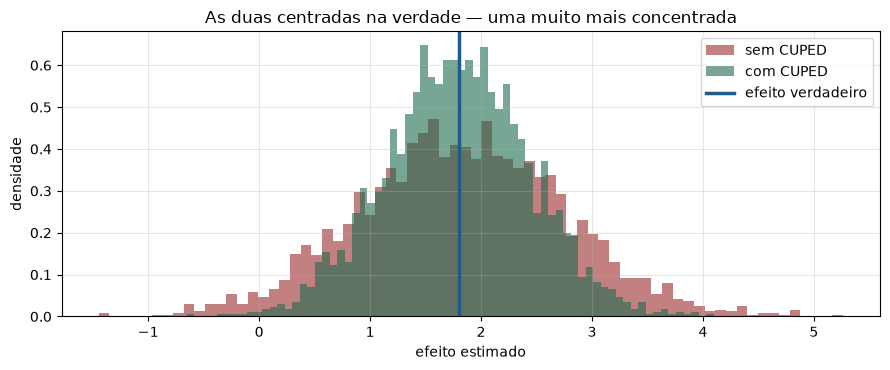

In [5]:
def um_experimento(n=8_000, efeito=1.8, semente=None):
    g = np.random.default_rng(semente)
    niv = g.gamma(2.0, 25.0, n)
    x = niv + g.normal(0, 22, n)
    tratado = g.random(n) < 0.5
    yy = niv + efeito * tratado + g.normal(0, 22, n)
    yc, _ = aplica_cuped(yy, x)
    return (yy[tratado].mean() - yy[~tratado].mean(),
            yc[tratado].mean() - yc[~tratado].mean())


estimativas = np.array([um_experimento(semente=s) for s in range(2500)])
sem, com = estimativas[:, 0], estimativas[:, 1]

print(f"{'':<14s} {'média das estimativas':>22s} {'viés':>10s} {'dp':>10s}")
print("-" * 60)
print(f"{'sem CUPED':<14s} {sem.mean():>22.4f} {sem.mean()-1.8:>10.4f} {sem.std():>10.4f}")
print(f"{'com CUPED':<14s} {com.mean():>22.4f} {com.mean()-1.8:>10.4f} {com.std():>10.4f}")
print(f"\nefeito verdadeiro: 1,8000")
print(f"redução do erro-padrão: {1 - com.std()/sem.std():.1%}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(sem, bins=70, alpha=0.6, color=VERMELHO, density=True, label="sem CUPED")
ax.hist(com, bins=70, alpha=0.6, color=VERDE, density=True, label="com CUPED")
ax.axvline(1.8, color=AZUL, lw=2.5, label="efeito verdadeiro")
ax.set_xlabel("efeito estimado"); ax.set_ylabel("densidade")
ax.set_title("As duas centradas na verdade — uma muito mais concentrada")
ax.legend(); plt.tight_layout(); plt.show()

Ambas centradas em 1,80 — **CUPED não desloca a estimativa**. Ele só aperta a
distribuição em torno dela. Esse é o gráfico que justifica adotar a técnica.

## 4. A condição inegociável: X precisa ser pré-tratamento

Usar uma covariável medida **durante** o experimento parece inofensivo e
introduz viés grave. Vamos ver o estrago.

                                  média       viés
----------------------------------------------------
sem ajuste                       1.8023     0.0023
CUPED com X PÓS-tratamento      -0.3624    -2.1624

O ajuste por covariável pós-tratamento REMOVEU parte do próprio efeito.


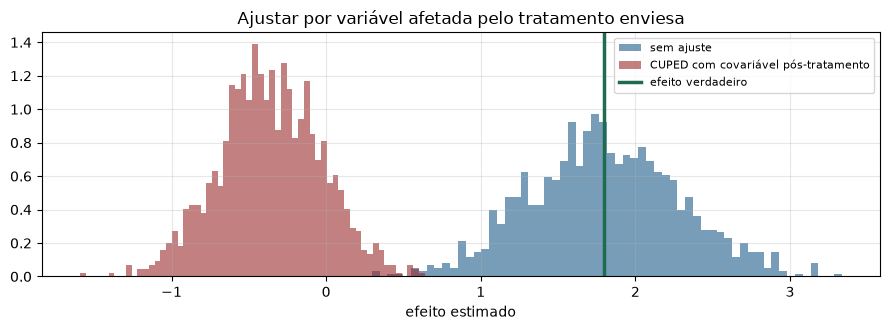

In [6]:
def experimento_com_covariavel_pos(n=30_000, efeito=1.8, semente=0):
    g = np.random.default_rng(semente)
    niv = g.gamma(2.0, 25.0, n)
    tratado = g.random(n) < 0.5
    yy = niv + efeito * tratado + g.normal(0, 22, n)
    # covariável PÓS-tratamento: é afetada pelo próprio tratamento
    x_pos = niv + 3.0 * tratado + g.normal(0, 22, n)
    yc, _ = aplica_cuped(yy, x_pos)
    return yy[tratado].mean() - yy[~tratado].mean(), yc[tratado].mean() - yc[~tratado].mean()


res = np.array([experimento_com_covariavel_pos(semente=s) for s in range(1200)])
print(f"{'':<28s} {'média':>10s} {'viés':>10s}")
print("-" * 52)
print(f"{'sem ajuste':<28s} {res[:,0].mean():>10.4f} {res[:,0].mean()-1.8:>10.4f}")
print(f"{'CUPED com X PÓS-tratamento':<28s} {res[:,1].mean():>10.4f} {res[:,1].mean()-1.8:>10.4f}")
print("\nO ajuste por covariável pós-tratamento REMOVEU parte do próprio efeito.")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(res[:, 0], bins=60, alpha=0.6, color=AZUL, density=True, label="sem ajuste")
ax.hist(res[:, 1], bins=60, alpha=0.6, color=VERMELHO, density=True,
        label="CUPED com covariável pós-tratamento")
ax.axvline(1.8, color=VERDE, lw=2.5, label="efeito verdadeiro")
ax.set_xlabel("efeito estimado"); ax.legend(fontsize=8)
ax.set_title("Ajustar por variável afetada pelo tratamento enviesa")
plt.tight_layout(); plt.show()

**A regra, sem exceção:** a covariável de CUPED tem que ser medida **antes da
aleatorização**. Não "antes do usuário ver a mudança", não "no começo do
experimento" — antes do sorteio.

Ajustar por algo que o tratamento influencia é condicionar em um descendente do
tratamento, e isso subtrai parte do efeito que você quer medir. Em inferência
causal isso tem nome: **viés de sobre-ajuste** (e, em outros arranjos, viés de
colisor). É o mesmo erro de "controlar" por uma variável mediadora numa
regressão.

## 5. Quanto de correlação você precisa

     ρ   redução de variância    ≈ economia de tráfego
--------------------------------------------------------
   0.1                  1.0%                    1.0%
   0.3                  9.0%                    9.0%
   0.5                 24.8%                   24.8%
   0.7                 48.6%                   48.6%
   0.9                 80.7%                   80.7%


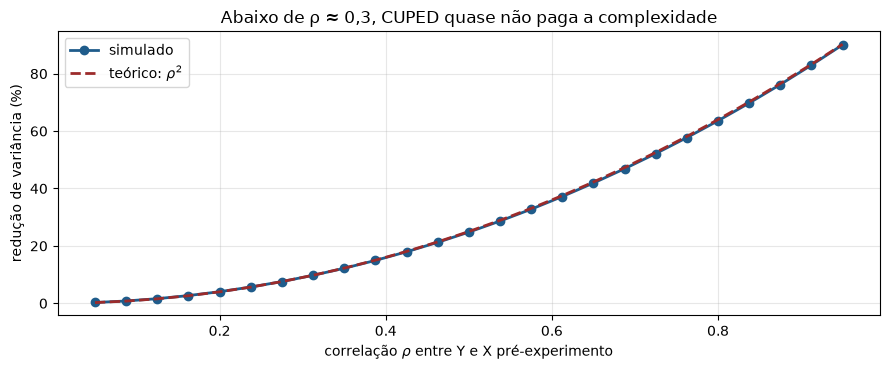

In [7]:
def simula_com_rho(rho_alvo, n=20_000, efeito=1.8, semente=0):
    g = np.random.default_rng(semente)
    x = g.normal(0, 1, n)
    ruido = g.normal(0, 1, n)
    y_base = rho_alvo * x + np.sqrt(1 - rho_alvo**2) * ruido
    tratado = g.random(n) < 0.5
    yy = 50 * y_base + efeito * tratado
    yc, _ = aplica_cuped(yy, x)
    ep_sem = np.sqrt(yy[tratado].var(ddof=1) / tratado.sum()
                     + yy[~tratado].var(ddof=1) / (~tratado).sum())
    ep_com = np.sqrt(yc[tratado].var(ddof=1) / tratado.sum()
                     + yc[~tratado].var(ddof=1) / (~tratado).sum())
    return ep_sem, ep_com


rhos = np.linspace(0.05, 0.95, 25)
reducoes = []
for r in rhos:
    ep_s, ep_c = simula_com_rho(r)
    reducoes.append(1 - (ep_c / ep_s) ** 2)

print(f"{'ρ':>6s} {'redução de variância':>22s} {'≈ economia de tráfego':>24s}")
print("-" * 56)
for r in [0.1, 0.3, 0.5, 0.7, 0.9]:
    ep_s, ep_c = simula_com_rho(r)
    red = 1 - (ep_c / ep_s) ** 2
    print(f"{r:>6.1f} {red:>21.1%} {red:>23.1%}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(rhos, np.array(reducoes) * 100, "o-", color=AZUL, lw=2, label="simulado")
ax.plot(rhos, rhos**2 * 100, color=VERMELHO, lw=2, ls="--", label=r"teórico: $\rho^2$")
ax.set_xlabel(r"correlação $\rho$ entre Y e X pré-experimento")
ax.set_ylabel("redução de variância (%)")
ax.set_title("Abaixo de ρ ≈ 0,3, CUPED quase não paga a complexidade")
ax.legend(); plt.tight_layout(); plt.show()

**A regra prática:** com $\rho < 0{,}3$, a redução é menor que 10% e
provavelmente não compensa a complexidade operacional. Com $\rho > 0{,}6$, a
redução passa de 35% e CUPED vira obrigatório.

**Onde a correlação costuma ser alta:** receita, tempo de uso e número de
sessões têm forte persistência individual ($\rho$ de 0,5 a 0,8). **Onde é
baixa:** conversão binária de evento raro, e qualquer métrica de usuários novos
— que, por definição, não têm passado. Times grandes rodam CUPED só na coorte
de usuários recorrentes e analisam novos separadamente.

## 6. Estratificação: a mesma ideia, para variáveis categóricas

Em vez de subtrair uma covariável contínua, calcule o efeito **dentro de cada
estrato** e combine com pesos populacionais.

In [8]:
N = 40_000
plataforma = rng.choice(["iOS", "Android", "Web"], N, p=[0.30, 0.45, 0.25])
base_por_plat = {"iOS": 90.0, "Android": 55.0, "Web": 130.0}
base = np.array([base_por_plat[p] for p in plataforma])

tratado = rng.random(N) < 0.5
receita = base + 2.0 * tratado + rng.normal(0, 20, N)

# estimador simples
dif_simples = receita[tratado].mean() - receita[~tratado].mean()
ep_simples = np.sqrt(receita[tratado].var(ddof=1) / tratado.sum()
                     + receita[~tratado].var(ddof=1) / (~tratado).sum())

# estimador estratificado: efeito dentro de cada estrato, ponderado
difs, vars_, pesos = [], [], []
for plat in np.unique(plataforma):
    m = plataforma == plat
    t, c = receita[m & tratado], receita[m & ~tratado]
    difs.append(t.mean() - c.mean())
    vars_.append(t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c))
    pesos.append(m.mean())
difs, vars_, pesos = np.array(difs), np.array(vars_), np.array(pesos)
dif_estrat = (pesos * difs).sum()
ep_estrat = np.sqrt((pesos**2 * vars_).sum())

print(f"{'estimador':<20s} {'efeito':>10s} {'erro-padrão':>14s} {'z':>8s}")
print("-" * 56)
print(f"{'simples':<20s} {dif_simples:>10.4f} {ep_simples:>14.4f} {dif_simples/ep_simples:>8.2f}")
print(f"{'estratificado':<20s} {dif_estrat:>10.4f} {ep_estrat:>14.4f} {dif_estrat/ep_estrat:>8.2f}")
print(f"\nefeito verdadeiro: 2,0000")
print(f"redução do erro-padrão: {1 - ep_estrat/ep_simples:.1%}")
print("\nefeito por estrato:", dict(zip(np.unique(plataforma), difs.round(3))))

estimador                efeito    erro-padrão        z
--------------------------------------------------------
simples                  1.4451         0.3625     3.99
estratificado            2.0547         0.1999    10.28

efeito verdadeiro: 2,0000
redução do erro-padrão: 44.9%

efeito por estrato: {np.str_('Android'): np.float64(1.792), np.str_('Web'): np.float64(2.455), np.str_('iOS'): np.float64(2.113)}


A estratificação remove a variância que vem de **os estratos serem
diferentes entre si** (Web gasta 130, Android 55). Se essa diferença explicar
muito da variância total, o ganho é grande.

> **Cuidado com os pesos:** use os pesos da **população**, fixos e conhecidos
> antes do experimento. Usar os pesos observados em cada grupo reintroduz
> ruído — e se os grupos tiverem composições ligeiramente diferentes, viés.

## 7. Winsorização: caudas pesadas e o que ela custa

Receita e tempo na página têm caudas que dominam a variância. Aparar o topo
reduz muito a variância — mas **muda o que você está estimando**.

limiar                variância  efeito est.         EP        z
------------------------------------------------------------------
sem winsorizar           120924      -2.5254     4.0155    -0.63
apara em p99.5            69081       0.2986     3.0350     0.10
apara em p99              57128       1.3313     2.7600     0.48
apara em p95              24913       3.6412     1.8225     2.00

efeito verdadeiro na média completa: 3,0000


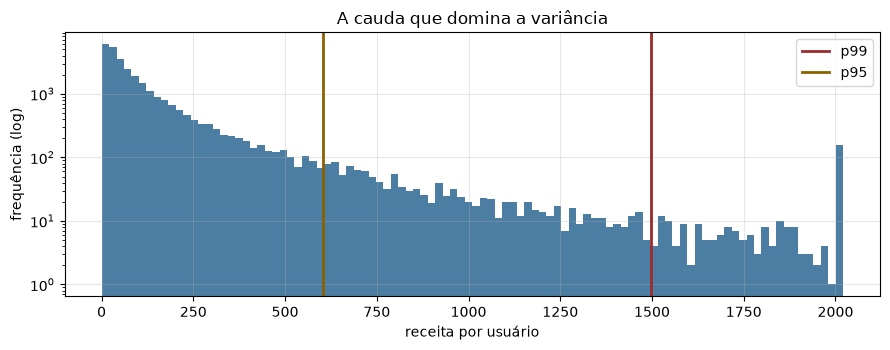

In [9]:
N = 30_000
tratado = rng.random(N) < 0.5
receita = rng.lognormal(np.log(60), 1.4, N) + 3.0 * tratado

print(f"{'limiar':<18s} {'variância':>12s} {'efeito est.':>12s} {'EP':>10s} {'z':>8s}")
print("-" * 66)
for pct in [100, 99.5, 99, 95]:
    if pct == 100:
        r = receita.copy()
    else:
        corte = np.percentile(receita, pct)
        r = np.minimum(receita, corte)
    dif = r[tratado].mean() - r[~tratado].mean()
    ep = np.sqrt(r[tratado].var(ddof=1) / tratado.sum()
                 + r[~tratado].var(ddof=1) / (~tratado).sum())
    rotulo = "sem winsorizar" if pct == 100 else f"apara em p{pct}"
    print(f"{rotulo:<18s} {r.var(ddof=1):>12.0f} {dif:>12.4f} {ep:>10.4f} {dif/ep:>8.2f}")
print(f"\nefeito verdadeiro na média completa: 3,0000")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(np.minimum(receita, np.percentile(receita, 99.5)), bins=100, color=AZUL, alpha=0.8)
ax.axvline(np.percentile(receita, 99), color=VERMELHO, lw=2, label="p99")
ax.axvline(np.percentile(receita, 95), color=AMBAR, lw=2, label="p95")
ax.set_yscale("log"); ax.set_xlabel("receita por usuário"); ax.set_ylabel("frequência (log)")
ax.set_title("A cauda que domina a variância"); ax.legend()
plt.tight_layout(); plt.show()

**O trade-off:** aparar em p99 reduz a variância drasticamente e o efeito
estimado ainda fica próximo do verdadeiro. Aparar em p95 reduz mais, e a
estimativa começa a se afastar — você passou a estimar o efeito na **média
aparada**, que é outra quantidade.

**Como usar sem se enganar:**

1. Defina o limiar **antes** de ver os dados do experimento (use um período
   histórico).
2. Aplique o **mesmo** limiar aos dois grupos — limiar calculado por grupo
   introduz viés.
3. **Declare** que a métrica é winsorizada. "Receita média por usuário
   (aparada em p99)" é honesto; "receita média" não é.
4. Reporte também a versão não aparada. Se as conclusões divergirem, a cauda
   é onde está a história.

## 8. Combinando as técnicas

In [10]:
N = 50_000
plataforma = rng.choice(["iOS", "Android", "Web"], N, p=[0.30, 0.45, 0.25])
nivel_plat = np.array([{"iOS": 90.0, "Android": 55.0, "Web": 130.0}[p] for p in plataforma])
nivel_usuario = rng.gamma(2.0, 15.0, N)

x_pre = nivel_plat + nivel_usuario + rng.normal(0, 25, N)
tratado = rng.random(N) < 0.5
y = nivel_plat + nivel_usuario + 2.5 * tratado + rng.normal(0, 25, N)


def ep_de(valores, mascara_trat):
    return np.sqrt(valores[mascara_trat].var(ddof=1) / mascara_trat.sum()
                   + valores[~mascara_trat].var(ddof=1) / (~mascara_trat).sum())


resultados = {}
resultados["bruto"] = (y[tratado].mean() - y[~tratado].mean(), ep_de(y, tratado))

y_c, _ = aplica_cuped(y, x_pre)
resultados["CUPED"] = (y_c[tratado].mean() - y_c[~tratado].mean(), ep_de(y_c, tratado))

# CUPED dentro de cada estrato, depois combinado
difs, vars_, pesos = [], [], []
for plat in np.unique(plataforma):
    m = plataforma == plat
    yc_m, _ = aplica_cuped(y[m], x_pre[m])
    t, c = yc_m[tratado[m]], yc_m[~tratado[m]]
    difs.append(t.mean() - c.mean())
    vars_.append(t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c))
    pesos.append(m.mean())
difs, vars_, pesos = np.array(difs), np.array(vars_), np.array(pesos)
resultados["CUPED + estratificado"] = ((pesos * difs).sum(), np.sqrt((pesos**2 * vars_).sum()))

ep_base = resultados["bruto"][1]
print(f"{'método':<26s} {'efeito':>10s} {'EP':>10s} {'z':>8s} {'n equivalente':>16s}")
print("-" * 76)
for nome, (efeito, ep) in resultados.items():
    equiv = (ep_base / ep) ** 2
    print(f"{nome:<26s} {efeito:>10.4f} {ep:>10.4f} {efeito/ep:>8.2f} {equiv:>15.2f}x")
print(f"\nefeito verdadeiro: 2,5000")

método                         efeito         EP        z    n equivalente
----------------------------------------------------------------------------
bruto                          2.4656     0.4008     6.15            1.00x
CUPED                          2.5827     0.2906     8.89            1.90x
CUPED + estratificado          2.3373     0.2665     8.77            2.26x

efeito verdadeiro: 2,5000


A coluna **n equivalente** é a forma de comunicar isso para quem decide
orçamento: "esta técnica faz nossos 50 mil usuários renderem o mesmo que 90
mil". Não é economia marginal — é capacidade de experimentação.

## O que levar deste notebook

- **$n \propto \sigma^2$**: cortar variância pela metade equivale a dobrar o
  tráfego, de graça.
- **CUPED** subtrai $\theta(X - \bar{X})$ com $X$ **pré-aleatorização**, e
  reduz a variância por $\rho^2$.
- **CUPED é não-viesado** — verificado por simulação, não assumido.
- **Covariável pós-tratamento enviesa**, removendo parte do próprio efeito.
- Abaixo de $\rho \approx 0{,}3$ não compensa; acima de 0,6 é obrigatório.
- **Estratificação** faz o mesmo para variáveis categóricas; use pesos
  populacionais fixos.
- **Winsorização** reduz muito a variância mas muda o estimando — declare o
  limiar, aplique igual nos dois grupos e reporte as duas versões.
- As técnicas **se combinam** e o ganho se acumula.

→ Próximo: o notebook de **exercícios** do módulo.